## Plot Hasil Manual Tuning - Relevance Dominant Only

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams["figure.figsize"] = (10, 6)

### Load Data

In [3]:
SUMMARY_PATH = "manual_tuning_summary_relevance_only.csv"

df = pd.read_csv(SUMMARY_PATH, sep=";", encoding="utf-8-sig")

print(f"Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Jumlah data: 2000 baris, 18 kolom


,scenario_group,K,alpha,beta,gamma,lambda_umkm,sold_weight,review_weight,rating_weight,discount_weight,Precision,Recall,F1_score,NDCG,Fairness,Unjudged@K,Relevant@K,Judged@K
0,relevance_dominant,10,0.50,0.25,0.25,0.03,0.40,0.60,0.40,0.60,0.78,0.11,0.19,0.83,1.00,0.00,7.83,10.00
1,relevance_dominant,10,0.50,0.25,0.25,0.03,0.40,0.60,0.50,0.50,0.78,0.11,0.19,0.82,1.00,0.00,7.83,10.00
2,relevance_dominant,10,0.50,0.25,0.25,0.03,0.40,0.60,0.60,0.40,0.78,0.11,0.19,0.82,1.00,0.00,7.83,10.00
3,relevance_dominant,10,0.50,0.25,0.25,0.03,0.40,0.60,0.70,0.30,0.77,0.11,0.19,0.81,1.00,0.00,7.67,10.00
4,relevance_dominant,10,0.50,0.25,0.25,0.03,0.50,0.50,0.40,0.60,0.78,0.11,0.19,0.83,1.00,0.00,7.83,10.00


In [5]:
metrics = ["Precision", "Recall", "F1_score", "NDCG", "Fairness"]
extra_metrics = ["Unjudged@K", "Relevant@K", "Judged@K"]
param_cols = [
    "K", "alpha", "beta", "gamma", "lambda_umkm",
    "sold_weight", "review_weight", "rating_weight", "discount_weight"
]

for col in metrics + extra_metrics + param_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values(["K", "lambda_umkm", "sold_weight", "review_weight", "rating_weight", "discount_weight"]).reset_index(drop=True)

### Rata-rata metrik per K

In [6]:
summary_per_k = (
    df.groupby("K", observed=True)[metrics + ["Unjudged@K", "Relevant@K", "Judged@K"]]
    .mean()
    .reset_index()
)

summary_per_k_display = summary_per_k.copy()

for col in metrics + ["Unjudged@K", "Relevant@K", "Judged@K"]:
    summary_per_k_display[col] = summary_per_k_display[col].map(lambda x: f"{x:.2f}")

summary_per_k_display

,K,Precision,Recall,F1_score,NDCG,Fairness,Unjudged@K,Relevant@K,Judged@K
0,10,0.81,0.11,0.20,0.85,1.00,0.00,8.09,10.00
1,20,0.79,0.22,0.34,0.82,1.00,0.00,15.82,20.00
2,30,0.76,0.32,0.44,0.79,1.00,0.00,22.87,29.98
3,40,0.73,0.40,0.51,0.77,1.00,0.01,29.25,39.78
4,50,0.69,0.47,0.55,0.73,1.00,0.03,34.46,48.27


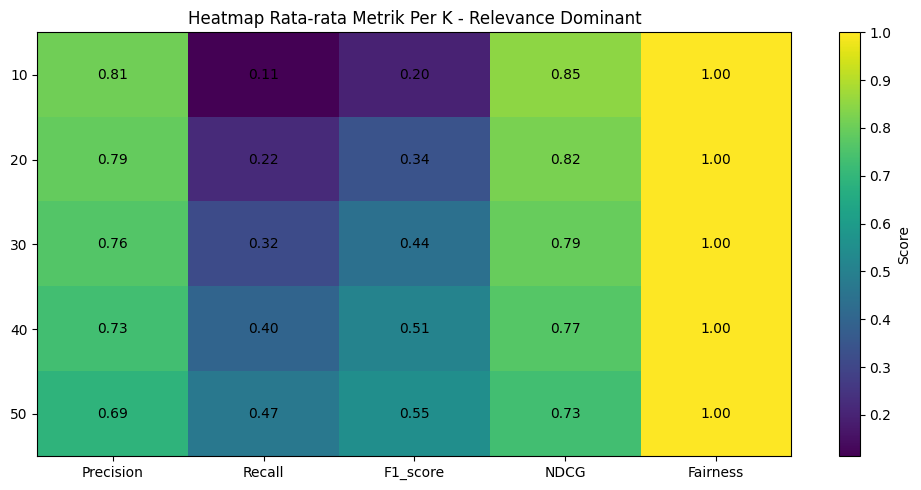

In [7]:
heatmap_data_k = summary_per_k.set_index("K")[metrics]

plt.figure(figsize=(10, 5))
plt.imshow(heatmap_data_k, aspect="auto")

plt.xticks(np.arange(len(metrics)), metrics)
plt.yticks(np.arange(len(heatmap_data_k.index)), heatmap_data_k.index)

plt.title("Heatmap Rata-rata Metrik Per K - Relevance Dominant")
plt.colorbar(label="Score")

for i in range(len(heatmap_data_k.index)):
    for j in range(len(metrics)):
        plt.text(
            j,
            i,
            f"{heatmap_data_k.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

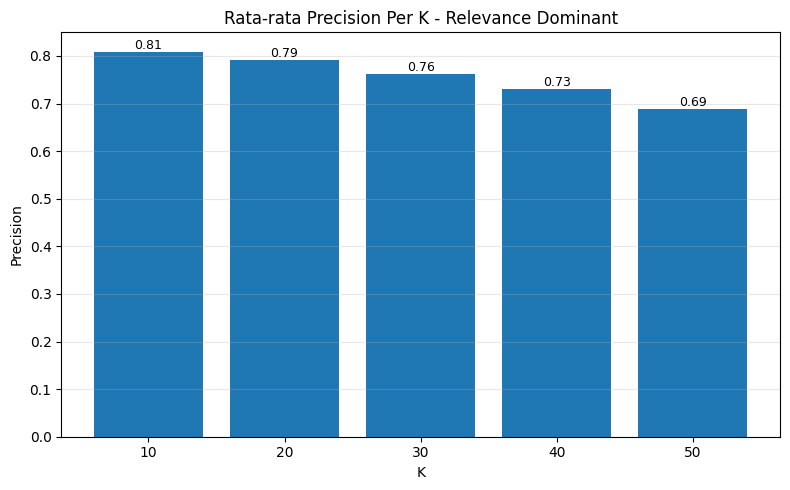

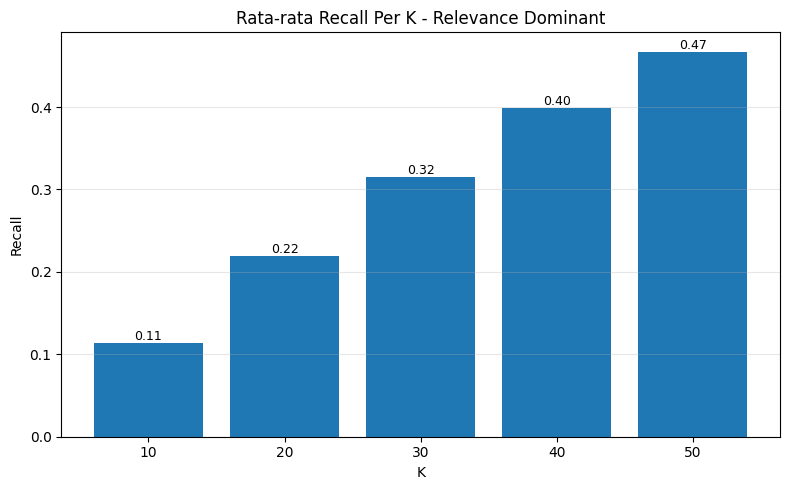

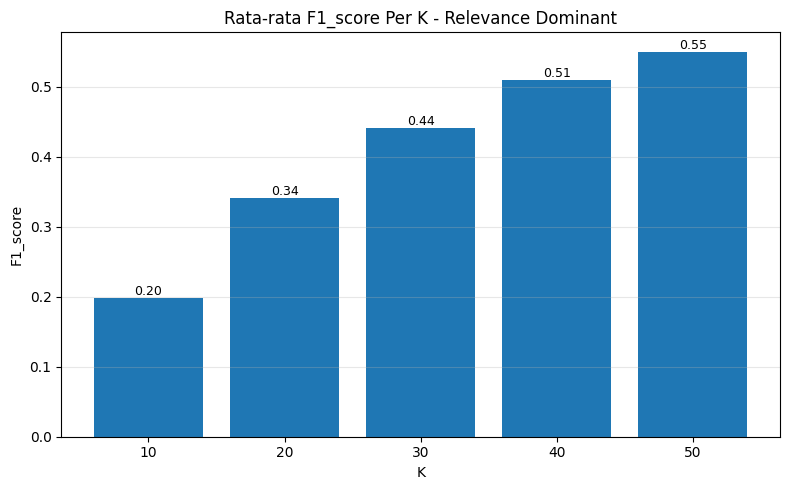

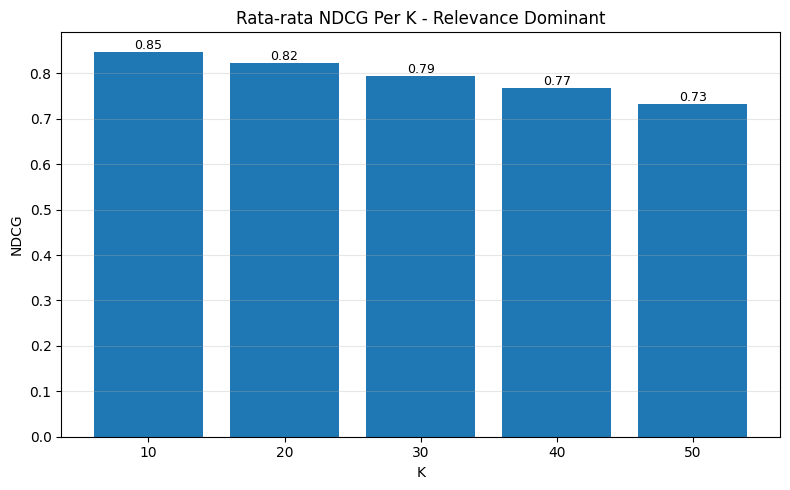

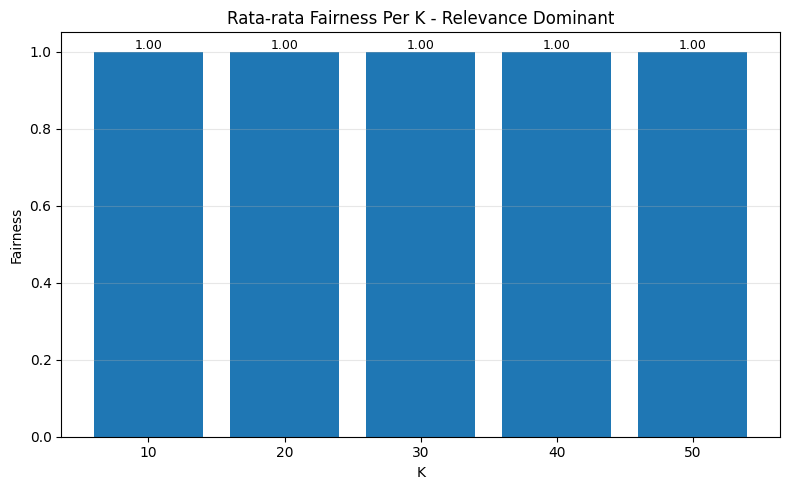

In [9]:
for metric in metrics:
    plt.figure(figsize=(8, 5))

    bars = plt.bar(
        summary_per_k["K"].astype(str),
        summary_per_k[metric]
    )

    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"{y:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.title(f"Rata-rata {metric} Per K - Relevance Dominant")
    plt.xlabel("K")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


### Analisis Kombinasi Terbaik

In [11]:
# ANALISIS KOMBINASI TERBAIK

result_cols = param_cols + metrics

df_rank = df.copy()

# metrik utama untuk menentukan kombinasi terbaik
rank_metrics = ["F1_score", "NDCG", "Precision", "Recall", "Fairness"]

# buat ranking untuk setiap metrik
# nilai metrik makin tinggi = ranking makin bagus
for col in rank_metrics:
    df_rank[col + "_rank"] = df_rank[col].rank(
        ascending=False,
        method="min"
    )

rank_cols = [col + "_rank" for col in rank_metrics]

# rata-rata ranking
# semakin kecil nilainya, semakin baik
df_rank["Average_rank"] = df_rank[rank_cols].mean(axis=1)

best_configs = (
    df_rank
    .sort_values("Average_rank", ascending=True)
    [result_cols + ["Average_rank"]]
    .head(10)
    .reset_index(drop=True)
)

best_configs

,K,alpha,beta,gamma,lambda_umkm,sold_weight,review_weight,rating_weight,discount_weight,Precision,Recall,F1_score,NDCG,Fairness,Average_rank
0,20,0.60,0.20,0.20,0.07,0.40,0.60,0.60,0.40,0.81,0.23,0.35,0.83,1.00,567.00
1,20,0.60,0.20,0.20,0.05,0.40,0.60,0.60,0.40,0.81,0.23,0.35,0.83,1.00,567.00
2,20,0.60,0.20,0.20,0.03,0.40,0.60,0.60,0.40,0.81,0.23,0.35,0.83,1.00,567.00
3,20,0.60,0.20,0.20,0.10,0.40,0.60,0.60,0.40,0.81,0.23,0.35,0.83,1.00,567.00
4,20,0.60,0.20,0.20,0.15,0.40,0.60,0.60,0.40,0.81,0.23,0.35,0.83,1.00,567.00
5,20,0.70,0.15,0.15,0.03,0.50,0.50,0.70,0.30,0.80,0.22,0.35,0.83,1.00,573.00
6,20,0.70,0.15,0.15,0.07,0.50,0.50,0.70,0.30,0.80,0.22,0.35,0.83,1.00,573.00
7,20,0.70,0.15,0.15,0.10,0.50,0.50,0.70,0.30,0.80,0.22,0.35,0.83,1.00,573.00
8,20,0.70,0.15,0.15,0.15,0.50,0.50,0.70,0.30,0.80,0.22,0.35,0.83,1.00,573.00
9,20,0.70,0.15,0.15,0.05,0.50,0.50,0.70,0.30,0.80,0.22,0.35,0.83,1.00,573.00


In [ ]:
best = best_configs.iloc[0]

print("KOMBINASI TERBAIK - RELEVANCE DOMINANT")
print("=======================================")
print(f"K              : {best['K']}")
print(f"alpha          : {best['alpha']:.2f}")
print(f"beta           : {best['beta']:.2f}")
print(f"gamma          : {best['gamma']:.2f}")
print(f"lambda_umkm    : {best['lambda_umkm']:.2f}")
print(f"sold_weight    : {best['sold_weight']:.2f}")
print(f"review_weight  : {best['review_weight']:.2f}")
print(f"rating_weight  : {best['rating_weight']:.2f}")
print(f"discount_weight: {best['discount_weight']:.2f}")

print()
print("HASIL METRIK")
print("============")
print(f"Precision      : {best['Precision']:.2f}")
print(f"Recall         : {best['Recall']:.2f}")
print(f"F1_score       : {best['F1_score']:.2f}")
print(f"NDCG           : {best['NDCG']:.2f}")
print(f"Fairness       : {best['Fairness']:.2f}")

KOMBINASI TERBAIK - RELEVANCE DOMINANT
K              : 20.0
alpha          : 0.60
beta           : 0.20
gamma          : 0.20
lambda_umkm    : 0.07
sold_weight    : 0.40
review_weight  : 0.60
rating_weight  : 0.60
discount_weight: 0.40

HASIL METRIK
Precision      : 0.81
Recall         : 0.23
F1_score       : 0.35
NDCG           : 0.83
Fairness       : 1.00
